In [1]:
# CLEAN IMPORT CELL — DO NOT INSTALL ANYTHING
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import itertools

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Colab cell 2 - load the npz
DATA_FILE = "/content/CWRU_48k_load_1_CNN_data.npz"  # change if different

# Option: if file not present, prompt upload
if not os.path.exists(DATA_FILE):
    from google.colab import files
    print("Please upload the CWRU npz file when prompted...")
    uploaded = files.upload()  # Choose your npz
    # pick the first file uploaded
    DATA_FILE = list(uploaded.keys())[0]

print("Loading:", DATA_FILE)
data = np.load(DATA_FILE, allow_pickle=True)
print("Keys in npz:", data.files)
# Inspect expected arrays (common names: X, y). Adapt if different.
for k in data.files:
    print(k, data[k].shape, data[k].dtype)


Loading: /content/CWRU_48k_load_1_CNN_data.npz
Keys in npz: ['data', 'labels']
data (4600, 32, 32) float64
labels (4600,) <U8


In [4]:
# Colab cell 3 - prepare arrays
# Replace keys if your npz uses other names (check previous print)
# Common names: 'X', 'y' OR 'data' / 'labels' etc.
if 'X' in data.files and 'y' in data.files:
    X = data['X']
    y = data['y']
elif 'x' in data.files and 'y' in data.files:
    X = data['x']; y = data['y']
else:
    # fallback: try to pick first 2 arrays
    keys = data.files
    X = data[keys[0]]
    y = data[keys[1]]
    print("Autoselected keys:", keys[0], keys[1])

# Ensure shapes: (n_samples, length) or (n_samples, length, 1)
print("Raw X shape:", X.shape, "y shape:", y.shape)

# If X is 2D (n_samples, length), expand dims for channels
if X.ndim == 2:
    X = np.expand_dims(X, axis=-1)  # shape -> (n_samples, length, 1)

# Convert labels to integers (if not already)
# If labels are strings, map them
if y.dtype.kind in {'U','S','O'}:
    unique = np.unique(y)
    label_map = {lab: i for i, lab in enumerate(unique)}
    y_int = np.array([label_map[lab] for lab in y])
else:
    y_int = y.astype(int)

num_classes = len(np.unique(y_int))
print("Num classes:", num_classes)

# Normalize signals per-sample (standardization) for stability
X = X.astype('float32')
# Option 1: per-sample z-score
eps = 1e-9
X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + eps)

# Train/val/test split (60/20/20)
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y_int, test_size=0.2, random_state=42, stratify=y_int)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval)
print("Shapes -> train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

# Convert to tf.data for performance
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(X_arr, y_arr, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X_arr, y_arr))
    if shuffle:
        ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds = make_dataset(X_val, y_val, shuffle=False)
test_ds = make_dataset(X_test, y_test, shuffle=False)


Autoselected keys: data labels
Raw X shape: (4600, 32, 32) y shape: (4600,)
Num classes: 10
Shapes -> train: (2760, 32, 32) val: (920, 32, 32) test: (920, 32, 32)


In [5]:
# Colab cell 4 - model definition
input_shape = X_train.shape[1:]  # (length, 1)
print("Input shape:", input_shape)

def build_light_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv1D(32, kernel_size=7, strides=1, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(pool_size=2)(x)

    # Block 2
    x = layers.Conv1D(48, kernel_size=5, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool1D(pool_size=2)(x)

    # Block 3 (light)
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

model = build_light_cnn(input_shape, num_classes)
model.summary()


Input shape: (32, 32)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 32, 32)         │         7,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 16, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 16, 48)         │         7,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 48)         │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 48)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 8, 64)          │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,594 (115.60 KB)

 Trainable params: 29,306 (114.48 KB)

 Non-trainable params: 288 (1.12 KB)

In [6]:
# Colab cell 5 - compile and callbacks
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint_cb = callbacks.ModelCheckpoint("best_light_cnn.h5", save_best_only=True, monitor='val_accuracy', mode='max')
earlystop_cb = callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
reduce_lr_cb = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

CALLBACKS = [checkpoint_cb, earlystop_cb, reduce_lr_cb]


In [7]:
# Colab cell 6 - train
EPOCHS = 60
history = model.fit(train_ds,
                    epochs=EPOCHS,
                    validation_data=val_ds,
                    callbacks=CALLBACKS)


Epoch 1/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.3311 - loss: 1.9345

44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.3354 - loss: 1.9252 - val_accuracy: 0.5315 - val_loss: 1.4535 - learning_rate: 0.0010
Epoch 2/60
39/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8459 - loss: 0.5795

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8502 - loss: 0.5632 - val_accuracy: 0.7598 - val_loss: 0.7049 - learning_rate: 0.0010
Epoch 3/60
39/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9363 - loss: 0.2284

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9375 - loss: 0.2248 - val_accuracy: 0.8859 - val_loss: 0.3379 - learning_rate: 0.0010
Epoch 4/60
38/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9641 - loss: 0.1337

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9644 - loss: 0.1326 - val_accuracy: 0.9478 - val_loss: 0.1715 - learning_rate: 0.0010
Epoch 5/60
38/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9699 - loss: 0.1188

...

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9962 - loss: 0.0261 - val_accuracy: 0.9739 - val_loss: 0.0603 - learning_rate: 0.0010
Epoch 11/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9957 - loss: 0.0192 - val_accuracy: 0.9728 - val_loss: 0.0768 - learning_rate: 0.0010
Epoch 12/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9941 - loss: 0.0197 - val_accuracy: 0.9739 - val_loss: 0.0627 - learning_rate: 0.0010
Epoch 13/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9692 - loss: 0.0955 - val_accuracy: 0.9630 - val_loss: 0.0926 - learning_rate: 0.0010
Epoch 14/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9885 - loss: 0.0354 - val_accuracy: 0.9707 - val_loss: 0.0776 - learning_rate: 0.0010
Epoch 15/60
34/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9939 - loss: 0.0206

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9937 - loss: 0.0211 - val_accuracy: 0.9750 - val_loss: 0.0646 - learning_rate: 5.0000e-04
Epoch 16/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9978 - loss: 0.0157 - val_accuracy: 0.9739 - val_loss: 0.0569 - learning_rate: 5.0000e-04
Epoch 17/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9974 - loss: 0.0141 - val_accuracy: 0.9739 - val_loss: 0.0666 - learning_rate: 5.0000e-04
Epoch 18/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9961 - loss: 0.0173 - val_accuracy: 0.9707 - val_loss: 0.0824 - learning_rate: 5.0000e-04
Epoch 19/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9944 - loss: 0.0204 - val_accuracy: 0.9707 - val_loss: 0.0751 - learning_rate: 5.0000e-04
Epoch 20/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9982 - loss: 0.0140 - val_accuracy: 0.9739 - val_loss: 0.0653 - learning_rate: 5.0000e-04
Epoch 21/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9997 - loss: 0.00

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9981 - loss: 0.0095 - val_accuracy: 0.9761 - val_loss: 0.0689 - learning_rate: 2.5000e-04
Epoch 23/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9995 - loss: 0.0064 - val_accuracy: 0.9750 - val_loss: 0.0664 - learning_rate: 2.5000e-04
Epoch 24/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9994 - loss: 0.0072 - val_accuracy: 0.9750 - val_loss: 0.0655 - learning_rate: 2.5000e-04
Epoch 25/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9999 - loss: 0.0051 - val_accuracy: 0.9761 - val_loss: 0.0643 - learning_rate: 1.2500e-04
Epoch 26/60
33/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0062

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9999 - loss: 0.0064 - val_accuracy: 0.9783 - val_loss: 0.0626 - learning_rate: 1.2500e-04
Epoch 27/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9991 - loss: 0.0073 - val_accuracy: 0.9772 - val_loss: 0.0624 - learning_rate: 1.2500e-04
Epoch 28/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9995 - loss: 0.0078 - val_accuracy: 0.9761 - val_loss: 0.0631 - learning_rate: 1.2500e-04
Epoch 29/60
35/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0074

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0073 - val_accuracy: 0.9793 - val_loss: 0.0611 - learning_rate: 6.2500e-05
Epoch 30/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9999 - loss: 0.0052 - val_accuracy: 0.9772 - val_loss: 0.0631 - learning_rate: 6.2500e-05
Epoch 31/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0060 - val_accuracy: 0.9750 - val_loss: 0.0641 - learning_rate: 6.2500e-05
Epoch 32/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9999 - loss: 0.0068 - val_accuracy: 0.9761 - val_loss: 0.0632 - learning_rate: 6.2500e-05
Epoch 33/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9988 - loss: 0.0051 - val_accuracy: 0.9761 - val_loss: 0.0625 - learning_rate: 3.1250e-05
Epoch 34/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0052 - val_accuracy: 0.9750 - val_loss: 0.0628 - learning_rate: 3.1250e-05
Epoch 35/60
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9998 - loss: 0.00

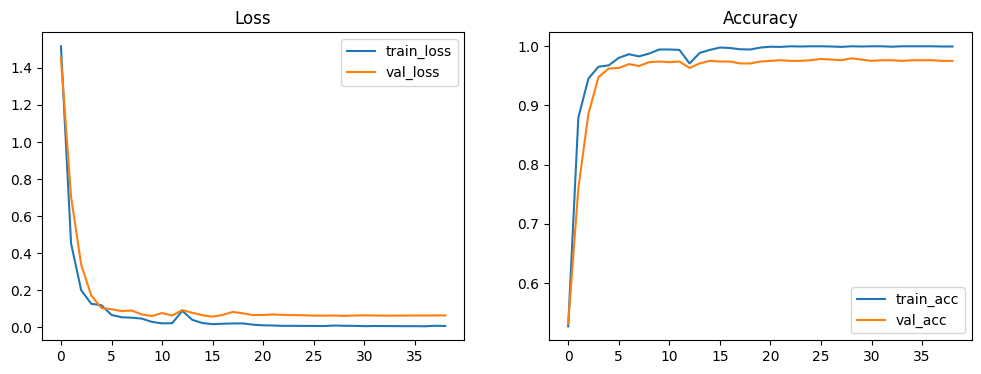

In [8]:
# Colab cell 7 - plots
def plot_history(hist):
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    ax[0].plot(hist.history['loss'], label='train_loss')
    ax[0].plot(hist.history['val_loss'], label='val_loss')
    ax[0].set_title('Loss'); ax[0].legend()

    ax[1].plot(hist.history['accuracy'], label='train_acc')
    ax[1].plot(hist.history['val_accuracy'], label='val_acc')
    ax[1].set_title('Accuracy'); ax[1].legend()
    plt.show()

plot_history(history)


In [9]:
# Colab cell 8 - evaluate and classification report
# Load best model (if saved)
if os.path.exists("best_light_cnn.h5"):
    model.load_weights("best_light_cnn.h5")

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}")

# Get predictions and classification report
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Build true labels in same order as batching from test_ds
y_true = np.concatenate([y for x,y in test_ds], axis=0)

print("Classification report:")
print(classification_report(y_true, y_pred, digits=4))


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9747 - loss: 0.0927
Test loss: 0.0785, Test acc: 0.9815
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
Classification report:
              precision    recall  f1-score   support

           0     0.9425    0.8913    0.9162        92
           1     1.0000    1.0000    1.0000        92
           2     1.0000    0.9783    0.9890        92
           3     1.0000    1.0000    1.0000        92
           4     1.0000    1.0000    1.0000        92
           5     0.9787    1.0000    0.9892        92
           6     1.0000    1.0000    1.0000        92
           7     1.0000    1.0000    1.0000        92
           8     0.8969    0.9457    0.9206        92
           9     1.0000    1.0000    1.0000        92

    accuracy                         0.9815       920
   macro avg     0.9818    0.9815    0.9815       920
weighted avg     0.9818    0.9815    0.9815       920



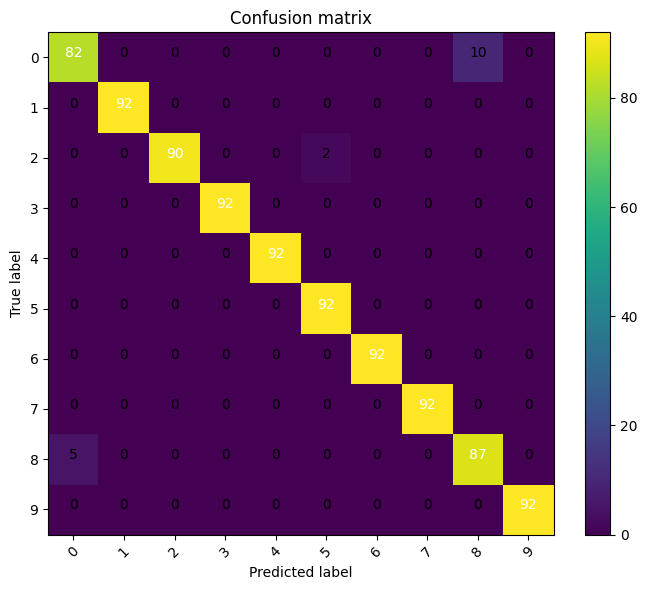

In [10]:
# Colab cell 9 - confusion matrix
cm = confusion_matrix(y_true, y_pred)
classes = [str(i) for i in range(num_classes)]

def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(7,6))
    plt.imshow(cm, interpolation='nearest', aspect='auto')
    plt.title('Confusion matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, classes)


In [12]:
# Colab cell 10 - save as TensorFlow SavedModel and TFLite (for mobile / real-time inference)
# SavedModel
model.export("light_cnn_savedmodel") # Changed to model.export for SavedModel

# TFLite conversion (optional)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Optional optimizations for smaller size / faster inference
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open("light_cnn.tflite", "wb") as f:
    f.write(tflite_model)
print("Saved TFLite model: light_cnn.tflite")


Saved artifact at 'light_cnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  133573286687760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133573224306384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133573224307536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133573224307344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133573224304656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133573224304464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133573224306192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133573224304848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133573224308496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133573224308688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13357322430676

In [13]:
# Colab cell 11 - single sample inference
sample = X_test[0:1]  # shape (1, length, 1)
probs = model.predict(sample)
pred_class = np.argmax(probs)
print("Predicted class:", pred_class, "probs:", probs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step
Predicted class: 8 probs: [[4.3662934e-04 4.6389832e-05 9.8718892e-06 1.0263070e-04 1.6406807e-07
  5.4168419e-07 2.6756994e-05 2.2449864e-05 9.9935120e-01 3.3526640e-06]]
